In [79]:
import os, gc, math, typing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist


print("TF:", tf.__version__, "| GPUs:", tf.config.list_physical_devices('GPU'))

SEQ_LEN = 30
FPS = 10
HORIZON_SECONDS = 3
HORIZON_FRAMES = HORIZON_SECONDS * FPS
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 100
PATIENCE =10
N_ROWS, N_COLS = 3, 9
NUM_ZONES = N_ROWS * N_COLS
N_PLAYERS = 3
N_OPPONENTS = 2
TOTAL_NODES = 6
K_EDGES = 3

# ── Capacity & regularisation ───────────────────────────────────────────────
# train_acc < val_acc in previous run → over-regularised, not overfitting.
# Slightly restore capacity and ease dropout/L2.
GCN_HIDDEN = 48       # 32→48 (was over-shrunk)
GCN_OUT = 48          # 32→48
TCN_FILTERS = 128      # 64→96
DROPOUT = 0.25        # 0.4→0.25 (0.4 caused train_acc < val_acc)
WINDOW_STEP = 5      # stride between windows (was 1 — caused 47k overlapping seqs)
L2_REG = 5e-5         # 1e-4→5e-5 (ease weight penalty)

CO_ORDINATES = False

FEATURE_COLS = [
    "x_normalized", "y_normalized",
    "dx_avg_3", "dy_avg_3", "speed_normalized", "acceleration", "movement_angle",
    "acceleration_trend", "angle_change", "angle_stability", "speed_change_rate",
    "distance_from_center", "distance_from_goal_home", "distance_from_goal_away",
    "distance_from_sideline", "distance_to_ball", "ball_possession_proximity", "team_spread",
    "home_score", "away_score", "nearest_opponent_1", "nearest_opponent_2", "nearest_opponent_3",
    "defensive_line_distance", "team_centroid_distance", "position_encoded"
]

COORD_COLS = ("x_normalized", "y_normalized")

TF: 2.19.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [80]:
train_df = pd.read_pickle('/kaggle/input/datasets/hashirhalaldeen/dataframes/train_df.pkl')
val_df = pd.read_pickle('/kaggle/input/datasets/hashirhalaldeen/dataframes/val_df.pkl')
test_df =pd.read_pickle('/kaggle/input/datasets/hashirhalaldeen/dataframes/test_df.pkl')
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

available = [c for c in FEATURE_COLS if c in df.columns]
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"Missing features (removed): {missing}")
    FEATURE_COLS = available

scaler = StandardScaler()
scaler.fit(train_df[FEATURE_COLS].values)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,} | Features: {len(FEATURE_COLS)}")
print(f"Matches: {df['match_id'].nunique()}, Players: {df['player_id'].nunique()}")

Train: 3,387,911 | Val: 699,902 | Test: 929,216 | Features: 26
Matches: 9, Players: 171


In [81]:
def _build_single_team(g, feature_cols, coord_cols, n_players):
    top_players = g["player_id"].value_counts().head(n_players).index.tolist()
    if len(top_players) < n_players:
        return None
    g = g[g["player_id"].isin(top_players)].copy()
    player_order = g.groupby("player_id")["x_normalized"].mean().sort_values().index.tolist()
    player_map = {p: i for i, p in enumerate(player_order)}
    g["node_idx"] = g["player_id"].map(player_map)
    g = g.sort_values(["frame_number", "node_idx"])
    fc = g.groupby("frame_number").size()
    valid_frames = sorted(fc[fc == n_players].index.tolist())
    g = g[g["frame_number"].isin(valid_frames)].sort_values(["frame_number", "node_idx"])
    n_frames = len(valid_frames)
    if n_frames < SEQ_LEN + HORIZON_FRAMES + 10:
        return None
    feats = np.nan_to_num(g[feature_cols].values, nan=0.0).reshape(n_frames, n_players, -1).astype(np.float32)
    coords = g[list(coord_cols)].values.reshape(n_frames, n_players, 2).astype(np.float32)
    frame_to_idx = {f: i for i, f in enumerate(valid_frames)}
    return {"features": feats, "coords": coords, "players": player_order, "frames": valid_frames, "frame_to_idx": frame_to_idx}

def build_team_tensors(df, feature_cols, coord_cols, n_players=N_PLAYERS, n_opponents=N_OPPONENTS):
    raw = {}
    for (mid, team), g in df.groupby(["match_id", "team_type"]):
        result = _build_single_team(g, feature_cols, coord_cols, n_players)
        if result is not None:
            raw[(mid, team)] = result

    matches = {}
    for (mid, team) in raw:
        matches.setdefault(mid, []).append(team)

    team_data = {}
    for mid, team_types in matches.items():
        for t in team_types:
            key = (mid, t)
            d = raw[key]
            opp_types = [x for x in team_types if x != t]
            if not opp_types or (mid, opp_types[0]) not in raw:
                n_frames = d["features"].shape[0]
                opp_feats = np.zeros((n_frames, n_opponents, len(feature_cols)), dtype=np.float32)
                opp_coords = np.zeros((n_frames, n_opponents, 2), dtype=np.float32)
                team_data[key] = {
                    "features": np.concatenate([d["features"], opp_feats], axis=1),
                    "coords": np.concatenate([d["coords"], opp_coords], axis=1),
                    "team_coords": d["coords"],
                    "players": d["players"]
                }
                continue

            opp_d = raw[(mid, opp_types[0])]
            common_frames = sorted(set(d["frames"]) & set(opp_d["frames"]))
            if len(common_frames) < SEQ_LEN + HORIZON_FRAMES + 10:
                continue

            t_idx = np.array([d["frame_to_idx"][f] for f in common_frames])
            o_idx = np.array([opp_d["frame_to_idx"][f] for f in common_frames])

            team_data[key] = {
                "features": np.concatenate([d["features"][t_idx], opp_d["features"][o_idx]], axis=1),
                "coords": np.concatenate([d["coords"][t_idx], opp_d["coords"][o_idx]], axis=1),
                "team_coords": d["coords"][t_idx],
                "players": d["players"]
            }
    return team_data

train_teams = build_team_tensors(train_df, FEATURE_COLS, COORD_COLS)
val_teams = build_team_tensors(val_df, FEATURE_COLS, COORD_COLS)
test_teams = build_team_tensors(test_df, FEATURE_COLS, COORD_COLS)
print(f"Graph teams -> Train: {len(train_teams)}, Val: {len(val_teams)}, Test: {len(test_teams)}")
for k, v in list(train_teams.items())[:3]:
    print(f"  {k}: {v['features'].shape[0]} frames, {v['features'].shape[1]} nodes ({N_PLAYERS}+{N_OPPONENTS}), {v['features'].shape[2]} feats")

Graph teams -> Train: 10, Val: 2, Test: 4
  (np.int16(2068), 'away'): 9877 frames, 6 nodes (3+2), 26 feats
  (np.int16(2068), 'home'): 9877 frames, 6 nodes (3+2), 26 feats
  (np.int16(2269), 'away'): 15969 frames, 6 nodes (3+2), 26 feats


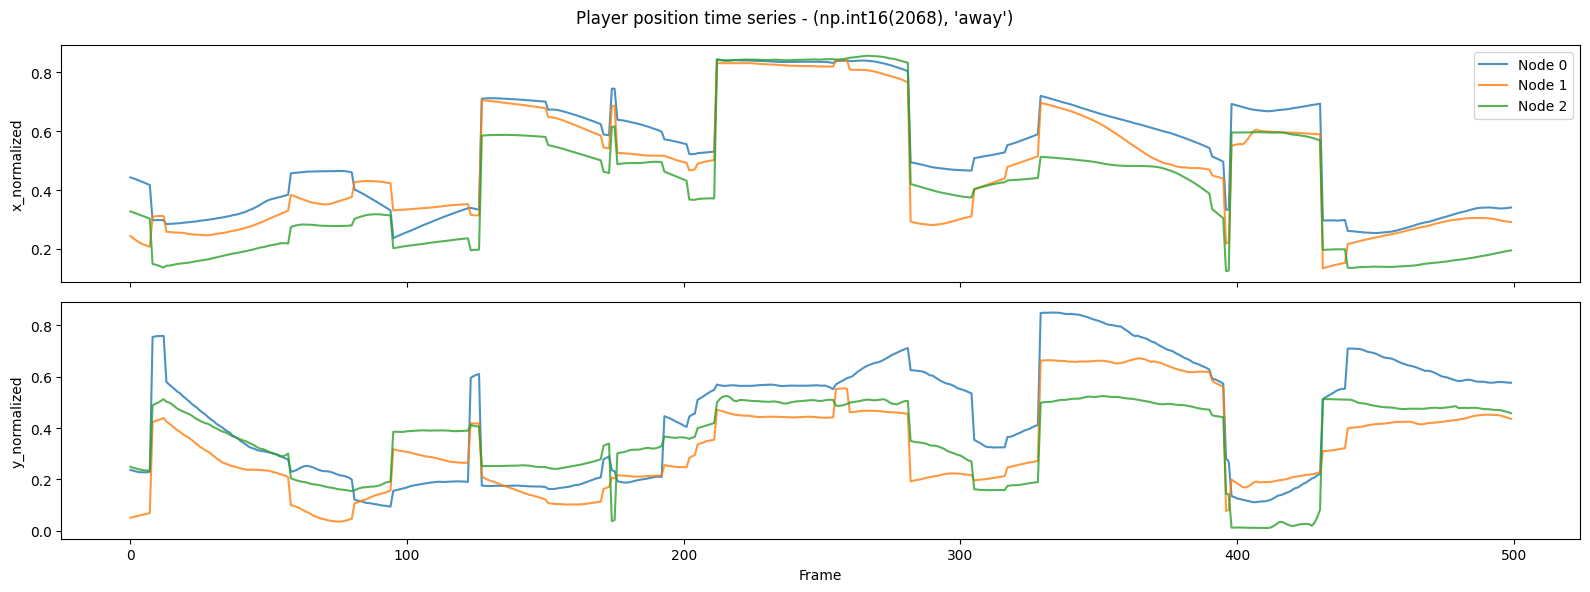

In [82]:
sample_key = list(train_teams.keys())[0]
sample = train_teams[sample_key]
coords = sample["team_coords"]

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
for p in [0, 1, 2]:
    axes[0].plot(coords[:500, p, 0], label=f"Node {p}", alpha=0.8)
    axes[1].plot(coords[:500, p, 1], label=f"Node {p}", alpha=0.8)
axes[0].set_ylabel("x_normalized")
axes[0].legend()
axes[1].set_ylabel("y_normalized")
axes[1].set_xlabel("Frame")
fig.suptitle(f"Player position time series - {sample_key}")
plt.tight_layout()
plt.show()

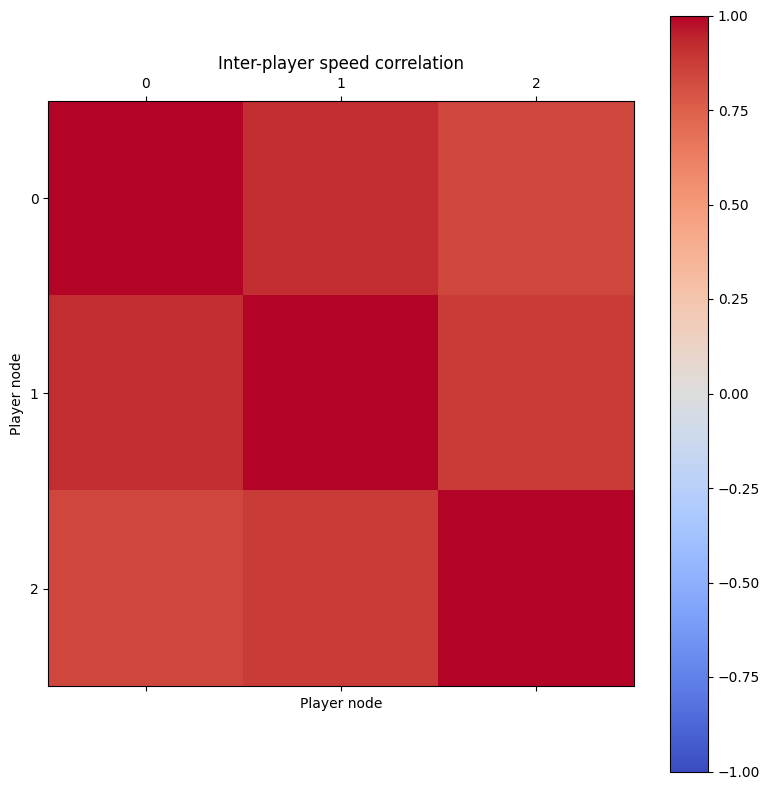

In [83]:
# EDA: Inter-player speed correlation heatmap (analogous to traffic route correlation)
speeds = np.sqrt(np.diff(coords[:, :, 0], axis=0)**2 + np.diff(coords[:, :, 1], axis=0)**2)
corr = np.corrcoef(speeds.T)

plt.figure(figsize=(8, 8))
plt.matshow(corr, 0, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xlabel("Player node")
plt.ylabel("Player node")
plt.title("Inter-player speed correlation")
plt.tight_layout()
plt.show()

Total nodes: 12
Nodes: 12, Edges: 52


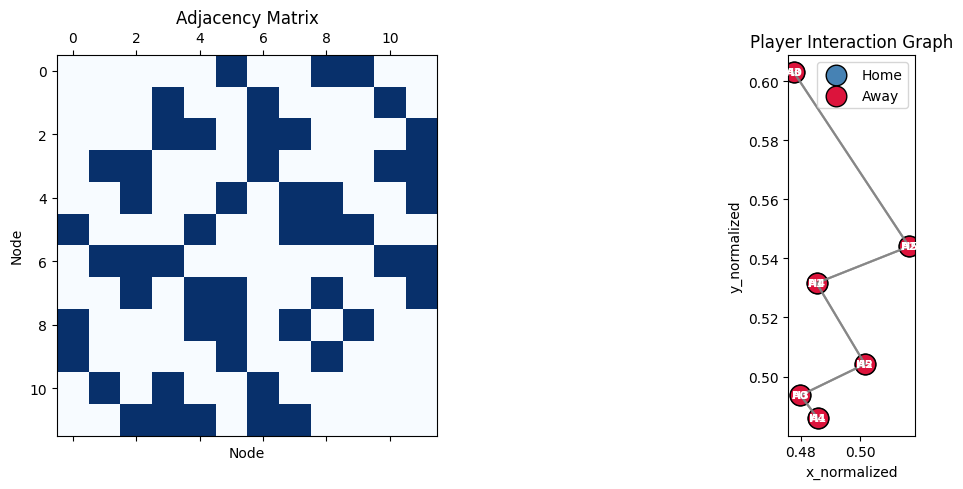

In [ ]:
class GraphInfo:
    def __init__(self, edges, num_nodes):
        self.edges = edges
        self.num_nodes = num_nodes


def compute_adjacency_knn(positions, k=K_EDGES):
    n = len(positions)
    dists = cdist(positions, positions)

    adj = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        neighbors = np.argsort(dists[i])[1:k+1]
        adj[i, neighbors] = 1
        adj[neighbors, i] = 1

    np.fill_diagonal(adj, 0)
    return adj


# -----------------------------
# Build graph from a single team entry
# Each entry already contains ALL nodes (own N_PLAYERS + N_OPPONENTS combined)
# -----------------------------
first_key = list(train_teams.keys())[0]
# coords: (n_frames, TOTAL_NODES, 2) — average across frames for stable positions
global_pos = train_teams[first_key]["coords"].mean(axis=0)   # (TOTAL_NODES, 2)
TOTAL_NODES = len(global_pos)

print("Total nodes:", TOTAL_NODES)

# -----------------------------
# Build graph
# -----------------------------
adj_matrix = compute_adjacency_knn(global_pos, k=K_EDGES)

node_i, node_j = np.where(adj_matrix == 1)

graph = GraphInfo(
    edges=(node_i.tolist(), node_j.tolist()),
    num_nodes=TOTAL_NODES
)

print(f"Nodes: {graph.num_nodes}, Edges: {len(graph.edges[0])}")


# -----------------------------
# Visualization
# -----------------------------
# Split positions back into team / opponent for colouring
team_pos = global_pos[:N_PLAYERS]
opp_pos  = global_pos[N_PLAYERS:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Adjacency matrix ---
axes[0].matshow(adj_matrix, cmap="Blues")
axes[0].set_title("Adjacency Matrix")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Node")

# --- Player graph ---
axes[1].scatter(team_pos[:, 0], team_pos[:, 1], s=220, color="steelblue",
                edgecolor="black", label="Team")
axes[1].scatter(opp_pos[:, 0], opp_pos[:, 1], s=220, color="crimson",
                edgecolor="black", label="Opponent")

for i in range(len(team_pos)):
    axes[1].annotate(f"T{i}", (team_pos[i, 0], team_pos[i, 1]),
                     ha="center", va="center", color="white", fontsize=8, fontweight="bold")
for i in range(len(opp_pos)):
    axes[1].annotate(f"O{i}", (opp_pos[i, 0], opp_pos[i, 1]),
                     ha="center", va="center", color="white", fontsize=8, fontweight="bold")

for i, j in zip(node_i, node_j):
    if i < j:
        axes[1].plot([global_pos[i, 0], global_pos[j, 0]],
                     [global_pos[i, 1], global_pos[j, 1]], color="gray", alpha=0.5)

axes[1].set_title("Player Interaction Graph")
axes[1].set_xlabel("x_normalized")
axes[1].set_ylabel("y_normalized")
axes[1].set_aspect("equal")
axes[1].legend()

plt.tight_layout()
plt.show()


In [85]:
def xy_to_zone_vectorized(xs, ys, n_rows, n_cols, flip_y=False):
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    if flip_y:
        ys = 1 - ys

    row = np.clip((ys * n_rows).astype(int), 0, n_rows - 1)
    col = np.clip((xs * n_cols).astype(int), 0, n_cols - 1)
    return row * n_cols + col


In [86]:
def gnn_generator(team_dict, scaler, shuffle=False):
    keys = list(team_dict.keys())

    if shuffle:
        np.random.shuffle(keys)

    n_feat = len(FEATURE_COLS)

    for key in keys:
        data = team_dict[key]

        feats = data["features"]              # (n_frames, total_nodes_for_sample, n_feat)
        team_coords = data["team_coords"]     # (n_frames, N_PLAYERS, 2)

        n_frames = feats.shape[0]

        flat_feats = feats.reshape(-1, n_feat)
        feats_scaled = scaler.transform(flat_feats).reshape(feats.shape)

        indices = list(range(0, n_frames - SEQ_LEN - HORIZON_FRAMES + 1, WINDOW_STEP))
        if shuffle:
            np.random.shuffle(indices)

        for i in indices:
            x = feats_scaled[i:i + SEQ_LEN]
            t_fut = i + SEQ_LEN - 1 + HORIZON_FRAMES

            if CO_ORDINATES:
                y = team_coords[t_fut].astype(np.float32)
                assert y.shape == (N_PLAYERS, 2), f"Bad y shape: {y.shape}"
            else:
                y = xy_to_zone_vectorized(
                    team_coords[t_fut, :, 0],
                    team_coords[t_fut, :, 1],
                    N_ROWS,
                    N_COLS
                ).astype(np.int32)
                assert y.shape == (N_PLAYERS,), f"Bad y shape: {y.shape}"

            yield x, y

In [87]:
def count_sequences(team_dict):
    # Use WINDOW_STEP stride to avoid ~identical overlapping windows
    return sum(
        len(range(0, max(0, d["features"].shape[0] - SEQ_LEN - HORIZON_FRAMES + 1), WINDOW_STEP))
        for d in team_dict.values()
    )


n_features = len(FEATURE_COLS)
if CO_ORDINATES:
    out_sig = (tf.TensorSpec((SEQ_LEN, TOTAL_NODES, n_features), tf.float32),
               tf.TensorSpec((N_PLAYERS, 2), tf.float32))
else:
    out_sig = (tf.TensorSpec((SEQ_LEN, TOTAL_NODES, n_features), tf.float32),
               tf.TensorSpec((N_PLAYERS,), tf.int32))

train_ds = tf.data.Dataset.from_generator(lambda: gnn_generator(train_teams, scaler, True), output_signature=out_sig)
val_ds = tf.data.Dataset.from_generator(lambda: gnn_generator(val_teams, scaler), output_signature=out_sig)
test_ds = tf.data.Dataset.from_generator(lambda: gnn_generator(test_teams, scaler), output_signature=out_sig)

train_seqs = count_sequences(train_teams)
val_seqs = count_sequences(val_teams)
test_seqs = count_sequences(test_teams)
train_steps = max(1, train_seqs // BATCH_SIZE)
val_steps = max(1, val_seqs // BATCH_SIZE)

train_ds = train_ds.shuffle(2048).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE).repeat()
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Train: {train_seqs:,} seqs ({train_steps} steps/epoch) | Val: {val_seqs:,} | Test: {test_seqs:,}")
print(f"  (WINDOW_STEP={WINDOW_STEP} — reduced from stride-1 to cut correlated sequences)")


Train: 21,040 seqs (328 steps/epoch) | Val: 9,956 | Test: 8,726
  (WINDOW_STEP=5 — reduced from stride-1 to cut correlated sequences)


In [88]:
class GraphConv(layers.Layer):
    def __init__(self, in_feat, out_feat, graph_info=None, aggregation="mean", l2_reg=0.0, **kwargs):
        super().__init__(**kwargs)
        self.in_feat = in_feat
        self.out_feat = out_feat
        self.aggregation = aggregation
        self.graph_info = graph_info
        self.l2_reg = l2_reg
        reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
        self.w_self  = self.add_weight(shape=(in_feat, out_feat), initializer="glorot_uniform",
                                       regularizer=reg, name="w_self")
        self.w_neigh = self.add_weight(shape=(in_feat, out_feat), initializer="glorot_uniform",
                                       regularizer=reg, name="w_neigh")
        self.bias    = self.add_weight(shape=(out_feat,), initializer="zeros", name="bias")
        self.norm    = layers.LayerNormalization()

    def call(self, features):
        if self.graph_info is None:
            raise ValueError("graph_info must be provided")
        self_out = tf.matmul(features, self.w_self)
        neighbor_feats = tf.gather(features, self.graph_info.edges[1])
        agg_fn = tf.math.unsorted_segment_mean if self.aggregation == "mean" else tf.math.unsorted_segment_sum
        agg = agg_fn(neighbor_feats, self.graph_info.edges[0], self.graph_info.num_nodes)
        neigh_out = tf.matmul(agg, self.w_neigh)
        out = self_out + neigh_out + self.bias
        return tf.nn.relu(self.norm(out))

    def get_config(self):
        config = super().get_config()
        config.update({"in_feat": self.in_feat, "out_feat": self.out_feat,
                        "aggregation": self.aggregation, "l2_reg": self.l2_reg})
        return config


In [89]:
import inspect
from typing import List  # noqa

import tensorflow as tf
try:
    # For TensorFlow 2.11+
    from keras.saving import register_keras_serializable
except ImportError:
    # For older TensorFlow versions
    from tensorflow.keras.utils import register_keras_serializable
# pylint: disable=E0611,E0401
from tensorflow.keras import backend as K, Model, Input, optimizers
# pylint: disable=E0611,E0401
from tensorflow.keras import layers
# pylint: disable=E0611,E0401
from tensorflow.keras.layers import Activation, SpatialDropout1D, Lambda
# pylint: disable=E0611,E0401
from tensorflow.keras.layers import Layer, Conv1D, Dense, BatchNormalization, LayerNormalization



# '''
# @misc{KerasTCN,
#   author = {Philippe Remy},
#   title = {Temporal Convolutional Networks for Keras},
#   year = {2020},
#   publisher = {GitHub},
#   journal = {GitHub repository},
#   howpublished = {\url{https://github.com/philipperemy/keras-tcn}},
# }
# '''

def is_power_of_two(num: int):
    return num != 0 and ((num & (num - 1)) == 0)


def adjust_dilations(dilations: list):
    if all([is_power_of_two(i) for i in dilations]):
        return dilations
    else:
        new_dilations = [2 ** i for i in dilations]
        return new_dilations


class ResidualBlock(Layer):

    def __init__(self,
                 dilation_rate: int,
                 nb_filters: int,
                 kernel_size: int,
                 padding: str,
                 activation: str = 'relu',
                 dropout_rate: float = 0,
                 kernel_initializer: str = 'he_normal',
                 use_batch_norm: bool = False,
                 use_layer_norm: bool = False,
                 **kwargs):
        """Defines the residual block for the WaveNet TCN
        Args:
            x: The previous layer in the model
            training: boolean indicating whether the layer should behave in training mode or in inference mode
            dilation_rate: The dilation power of 2 we are using for this residual block
            nb_filters: The number of convolutional filters to use in this block
            kernel_size: The size of the convolutional kernel
            padding: The padding used in the convolutional layers, 'same' or 'causal'.
            activation: The final activation used in o = Activation(x + F(x))
            dropout_rate: Float between 0 and 1. Fraction of the input units to drop.
            kernel_initializer: Initializer for the kernel weights matrix (Conv1D).
            use_batch_norm: Whether to use batch normalization in the residual layers or not.
            use_layer_norm: Whether to use layer normalization in the residual layers or not.
            kwargs: Any initializers for Layer class.
        """

        self.dilation_rate = dilation_rate
        self.nb_filters = nb_filters
        self.kernel_size = kernel_size
        self.padding = padding
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.use_batch_norm = use_batch_norm
        self.use_layer_norm = use_layer_norm
        self.kernel_initializer = kernel_initializer
        self.layers = []
        self.shape_match_conv = None
        self.res_output_shape = None
        self.final_activation = None
        self.batch_norm_layers = []
        self.layer_norm_layers = []

        super(ResidualBlock, self).__init__(**kwargs)

    def _build_layer(self, layer):
        """Helper function for building layer
        Args:
            layer: Appends layer to internal layer list and builds it based on the current output
                   shape of ResidualBlocK. Updates current output shape.
        """
        self.layers.append(layer)
        self.layers[-1].build(self.res_output_shape)
        self.res_output_shape = self.layers[-1].compute_output_shape(self.res_output_shape)

    def build(self, input_shape):

        with K.name_scope(self.name):  # name scope used to make sure weights get unique names
            self.layers = []
            self.res_output_shape = input_shape

            for k in range(2):  # dilated conv block.
                name = 'conv1D_{}'.format(k)
                with K.name_scope(name):  # name scope used to make sure weights get unique names
                    conv = Conv1D(
                        filters=self.nb_filters,
                        kernel_size=self.kernel_size,
                        dilation_rate=self.dilation_rate,
                        padding=self.padding,
                        name=name,
                        kernel_initializer=self.kernel_initializer
                    )
                    self._build_layer(conv)

                with K.name_scope('norm_{}'.format(k)):
                    if self.use_batch_norm:
                        bn_layer = BatchNormalization()
                        self.batch_norm_layers.append(bn_layer)
                        self._build_layer(bn_layer)
                    elif self.use_layer_norm:
                        ln_layer = LayerNormalization()
                        self.layer_norm_layers.append(ln_layer)
                        self._build_layer(ln_layer)

                with K.name_scope('act_and_dropout_{}'.format(k)):
                    self._build_layer(Activation(self.activation, name='Act_Conv1D_{}'.format(k)))
                    self._build_layer(SpatialDropout1D(rate=self.dropout_rate, name='SDropout_{}'.format(k)))

            if self.nb_filters != input_shape[-1]:
                # 1x1 conv to match the shapes (channel dimension).
                name = 'matching_conv1D'
                with K.name_scope(name):
                    # make and build this layer separately because it directly uses input_shape.
                    # 1x1 conv.
                    self.shape_match_conv = Conv1D(
                        filters=self.nb_filters,
                        kernel_size=1,
                        padding='same',
                        name=name,
                        kernel_initializer=self.kernel_initializer
                    )
            else:
                name = 'matching_identity'
                self.shape_match_conv = Lambda(lambda x: x, name=name)

            with K.name_scope(name):
                self.shape_match_conv.build(input_shape)
                self.res_output_shape = self.shape_match_conv.compute_output_shape(input_shape)

            self._build_layer(Activation(self.activation, name='Act_Conv_Blocks'))
            self.final_activation = Activation(self.activation, name='Act_Res_Block')
            self.final_activation.build(self.res_output_shape)  # probably isn't necessary

            # this is done to force Keras to add the layers in the list to self._layers
            for layer in self.layers:
                self.__setattr__(layer.name, layer)
            self.__setattr__(self.shape_match_conv.name, self.shape_match_conv)
            self.__setattr__(self.final_activation.name, self.final_activation)

            super(ResidualBlock, self).build(input_shape)  # done to make sure self.built is set True

    def call(self, inputs, training=None, **kwargs):
        """
        Returns: A tuple where the first element is the residual model tensor, and the second
                 is the skip connection tensor.
        """
        # https://arxiv.org/pdf/1803.01271.pdf  page 4, Figure 1 (b).
        # x1: Dilated Conv -> Norm -> Dropout (x2).
        # x2: Residual (1x1 matching conv - optional).
        # Output: x1 + x2.
        # x1 -> connected to skip connections.
        # x1 + x2 -> connected to the next block.
        #       input
        #     x1      x2
        #   conv1D    1x1 Conv1D (optional)
        #    ...
        #   conv1D
        #    ...
        #       x1 + x2
        x1 = inputs
        for layer in self.layers:
            training_flag = 'training' in dict(inspect.signature(layer.call).parameters)
            x1 = layer(x1, training=training) if training_flag else layer(x1)
        x2 = self.shape_match_conv(inputs)
        x1_x2 = self.final_activation(layers.add([x2, x1], name='Add_Res'))
        return [x1_x2, x1]

    def compute_output_shape(self, input_shape):
        return [self.res_output_shape, self.res_output_shape]


@register_keras_serializable()
class TCN(Layer):
    """Creates a TCN layer.

        Input shape:
            A 3D tensor with shape (batch_size, timesteps, input_dim).

        Args:
            nb_filters: The number of filters to use in the convolutional layers. Can be a list.
            kernel_size: The size of the kernel to use in each convolutional layer.
            dilations: The list of the dilations. Example is: [1, 2, 4, 8, 16, 32, 64].
            nb_stacks : The number of stacks of residual blocks to use.
            padding: The padding to use in the convolutional layers, 'causal' or 'same'.
            use_skip_connections: Boolean. If we want to add skip connections from input to each residual blocK.
            return_sequences: Boolean. Whether to return the last output in the output sequence, or the full sequence.
            activation: The activation used in the residual blocks o = Activation(x + F(x)).
            dropout_rate: Float between 0 and 1. Fraction of the input units to drop.
            kernel_initializer: Initializer for the kernel weights matrix (Conv1D).
            use_batch_norm: Whether to use batch normalization in the residual layers or not.
            use_layer_norm: Whether to use layer normalization in the residual layers or not.
            go_backwards: Boolean (default False). If True, process the input sequence backwards and
            return the reversed sequence.
            return_state: Boolean. Whether to return the last state in addition to the output. Default: False.
            kwargs: Any other arguments for configuring parent class Layer. For example "name=str", Name of the model.
                    Use unique names when using multiple TCN.
        Returns:
            A TCN layer.
        """

    def __init__(self,
                 nb_filters=64,
                 kernel_size=3,
                 nb_stacks=1,
                 dilations=(1, 2, 4, 8, 16, 32),
                 padding='causal',
                 use_skip_connections=True,
                 dropout_rate=0.0,
                 return_sequences=False,
                 activation='relu',
                 kernel_initializer='he_normal',
                 use_batch_norm=False,
                 use_layer_norm=False,
                 go_backwards=False,
                 return_state=False,
                 **kwargs):
        self.stateful = False  # TCN are not stateful. Keras requires this parameter.
        self.return_sequences = return_sequences
        self.dropout_rate = dropout_rate
        self.use_skip_connections = use_skip_connections
        self.dilations = dilations
        self.nb_stacks = nb_stacks
        self.kernel_size = kernel_size
        self.nb_filters = nb_filters
        self.activation_name = activation
        self.padding = padding
        self.kernel_initializer = kernel_initializer
        self.use_batch_norm = use_batch_norm
        self.use_layer_norm = use_layer_norm
        self.go_backwards = go_backwards
        self.return_state = return_state
        self.skip_connections = []
        self.residual_blocks = []
        self.layers_outputs = []
        self.build_output_shape = None
        self.slicer_layer = None  # in case return_sequence=False
        self.output_slice_index = None  # in case return_sequence=False
        self.padding_same_and_time_dim_unknown = False  # edge case if padding='same' and time_dim = None

        if self.use_batch_norm + self.use_layer_norm > 1:
            raise ValueError('Only one normalization can be specified at once.')

        if isinstance(self.nb_filters, list):
            assert len(self.nb_filters) == len(self.dilations)
            if len(set(self.nb_filters)) > 1 and self.use_skip_connections:
                raise ValueError('Skip connections are not compatible '
                                 'with a list of filters, unless they are all equal.')

        if padding != 'causal' and padding != 'same':
            raise ValueError("Only 'causal' or 'same' padding are compatible for this layer.")

        # initialize parent class
        super(TCN, self).__init__(**kwargs)

    @property
    def receptive_field(self):
        return 1 + 2 * (self.kernel_size - 1) * self.nb_stacks * sum(self.dilations)

    def tolist(self, shape):
        # noinspection PyBroadException
        try:
            return shape.as_list()
        except Exception:
            return list(shape)

    def build(self, input_shape):

        # member to hold current output shape of the layer for building purposes
        self.build_output_shape = input_shape

        # list to hold all the member ResidualBlocks
        self.residual_blocks = []
        total_num_blocks = self.nb_stacks * len(self.dilations)
        if not self.use_skip_connections:
            total_num_blocks += 1  # cheap way to do a false case for below

        for s in range(self.nb_stacks):
            for i, d in enumerate(self.dilations):
                res_block_filters = self.nb_filters[i] if isinstance(self.nb_filters, list) else self.nb_filters
                self.residual_blocks.append(ResidualBlock(dilation_rate=d,
                                                          nb_filters=res_block_filters,
                                                          kernel_size=self.kernel_size,
                                                          padding=self.padding,
                                                          activation=self.activation_name,
                                                          dropout_rate=self.dropout_rate,
                                                          use_batch_norm=self.use_batch_norm,
                                                          use_layer_norm=self.use_layer_norm,
                                                          kernel_initializer=self.kernel_initializer,
                                                          name='residual_block_{}'.format(len(self.residual_blocks))))
                # build newest residual block
                self.residual_blocks[-1].build(self.build_output_shape)
                self.build_output_shape = self.residual_blocks[-1].res_output_shape

        # this is done to force keras to add the layers in the list to self._layers
        for layer in self.residual_blocks:
            self.__setattr__(layer.name, layer)

        self.output_slice_index = None
        if self.padding == 'same':
            time = self.tolist(self.build_output_shape)[1]
            if time is not None:  # if time dimension is defined. e.g. shape = (bs, 500, input_dim).
                self.output_slice_index = int(self.tolist(self.build_output_shape)[1] / 2)
            else:
                # It will known at call time. c.f. self.call.
                self.padding_same_and_time_dim_unknown = True

        else:
            self.output_slice_index = -1  # causal case.
        self.slicer_layer = Lambda(lambda tt: tt[:, self.output_slice_index, :], name='Slice_Output')
        self.slicer_layer.build(self.tolist(self.build_output_shape))

    def compute_output_shape(self, input_shape):
        """
        Overridden in case keras uses it somewhere... no idea. Just trying to avoid future errors.
        """
        if not self.built:
            self.build(input_shape)
        if not self.return_sequences:
            batch_size = self.build_output_shape[0]
            batch_size = batch_size.value if hasattr(batch_size, 'value') else batch_size
            nb_filters = self.build_output_shape[-1]
            return [batch_size, nb_filters]
        else:
            # Compatibility tensorflow 1.x
            return [v.value if hasattr(v, 'value') else v for v in self.build_output_shape]

    def call(self, inputs, training=None, **kwargs):
        x = inputs

        if self.go_backwards:
            # reverse x in the time axis
            x = tf.reverse(x, axis=[1])

        self.layers_outputs = [x]
        self.skip_connections = []
        for res_block in self.residual_blocks:
            try:
                x, skip_out = res_block(x, training=training)
            except TypeError:  # compatibility with tensorflow 1.x
                x, skip_out = res_block(K.cast(x, 'float32'), training=training)
            self.skip_connections.append(skip_out)
            self.layers_outputs.append(x)

        if self.use_skip_connections:
            if len(self.skip_connections) > 1:
                # Keras: A merge layer should be called on a list of at least 2 inputs. Got 1 input.
                x = layers.add(self.skip_connections, name='Add_Skip_Connections')
            else:
                x = self.skip_connections[0]
            self.layers_outputs.append(x)

        if not self.return_sequences:
            # case: time dimension is unknown. e.g. (bs, None, input_dim).
            if self.padding_same_and_time_dim_unknown:
                self.output_slice_index = K.shape(self.layers_outputs[-1])[1] // 2
            x = self.slicer_layer(x)
            self.layers_outputs.append(x)
        return x

    def get_config(self):
        """
        Returns the config of a the layer. This is used for saving and loading from a model
        :return: python dictionary with specs to rebuild layer
        """
        config = super(TCN, self).get_config()
        config['nb_filters'] = self.nb_filters
        config['kernel_size'] = self.kernel_size
        config['nb_stacks'] = self.nb_stacks
        config['dilations'] = self.dilations
        config['padding'] = self.padding
        config['use_skip_connections'] = self.use_skip_connections
        config['dropout_rate'] = self.dropout_rate
        config['return_sequences'] = self.return_sequences
        config['activation'] = self.activation_name
        config['use_batch_norm'] = self.use_batch_norm
        config['use_layer_norm'] = self.use_layer_norm
        config['kernel_initializer'] = self.kernel_initializer
        config['go_backwards'] = self.go_backwards
        config['return_state'] = self.return_state
        return config


def compiled_tcn(num_feat,  # type: int
                 num_classes,  # type: int
                 nb_filters,  # type: int
                 kernel_size,  # type: int
                 dilations,  # type: List[int]
                 nb_stacks,  # type: int
                 max_len,  # type: int
                 output_len=1,  # type: int
                 padding='causal',  # type: str
                 use_skip_connections=False,  # type: bool
                 return_sequences=True,
                 regression=False,  # type: bool
                 dropout_rate=0.05,  # type: float
                 name='tcn',  # type: str,
                 kernel_initializer='he_normal',  # type: str,
                 activation='relu',  # type:str,
                 opt='adam',
                 lr=0.002,
                 use_batch_norm=False,
                 use_layer_norm=False):
    # type: (...) -> Model
    """Creates a compiled TCN model for a given task (i.e. regression or classification).
    Classification uses a sparse categorical loss. Please input class ids and not one-hot encodings.

    Args:
        num_feat: The number of features of your input, i.e. the last dimension of: (batch_size, timesteps, input_dim).
        num_classes: The size of the final dense layer, how many classes we are predicting.
        nb_filters: The number of filters to use in the convolutional layers.
        kernel_size: The size of the kernel to use in each convolutional layer.
        dilations: The list of the dilations. Example is: [1, 2, 4, 8, 16, 32, 64].
        nb_stacks : The number of stacks of residual blocks to use.
        max_len: The maximum sequence length, use None if the sequence length is dynamic.
        padding: The padding to use in the convolutional layers.
        use_skip_connections: Boolean. If we want to add skip connections from input to each residual blocK.
        return_sequences: Boolean. Whether to return the last output in the output sequence, or the full sequence.
        regression: Whether the output should be continuous or discrete.
        dropout_rate: Float between 0 and 1. Fraction of the input units to drop.
        activation: The activation used in the residual blocks o = Activation(x + F(x)).
        name: Name of the model. Useful when having multiple TCN.
        kernel_initializer: Initializer for the kernel weights matrix (Conv1D).
        opt: Optimizer name.
        lr: Learning rate.
        use_batch_norm: Whether to use batch normalization in the residual layers or not.
        use_layer_norm: Whether to use layer normalization in the residual layers or not.
    Returns:
        A compiled keras TCN.
    """

    dilations = adjust_dilations(dilations)

    input_layer = Input(shape=(max_len, num_feat))

    x = TCN(nb_filters, kernel_size, nb_stacks, dilations, padding,
            use_skip_connections, dropout_rate, return_sequences,
            activation, kernel_initializer, use_batch_norm, use_layer_norm,
            name=name)(input_layer)

    print('x.shape=', x.shape)

    def get_opt():
        if opt == 'adam':
            return optimizers.Adam(lr=lr, clipnorm=1.)
        elif opt == 'rmsprop':
            return optimizers.RMSprop(lr=lr, clipnorm=1.)
        else:
            raise Exception('Only Adam and RMSProp are available here')

    if not regression:
        # classification
        x = Dense(num_classes)(x)
        x = Activation('softmax')(x)
        output_layer = x
        model = Model(input_layer, output_layer)

        # https://github.com/keras-team/keras/pull/11373
        # It's now in Keras@master but still not available with pip.
        # TODO remove later.
        def accuracy(y_true, y_pred):
            # reshape in case it's in shape (num_samples, 1) instead of (num_samples,)
            if K.ndim(y_true) == K.ndim(y_pred):
                y_true = K.squeeze(y_true, -1)
            # convert dense predictions to labels
            y_pred_labels = K.argmax(y_pred, axis=-1)
            y_pred_labels = K.cast(y_pred_labels, K.floatx())
            return K.cast(K.equal(y_true, y_pred_labels), K.floatx())

        model.compile(get_opt(), loss='sparse_categorical_crossentropy', metrics=[accuracy])
    else:
        # regression
        x = Dense(output_len)(x)
        x = Activation('linear')(x)
        output_layer = x
        model = Model(input_layer, output_layer)
        model.compile(get_opt(), loss='mean_squared_error')
    print('model.x = {}'.format(input_layer.shape))
    print('model.y = {}'.format(output_layer.shape))
    return model


def tcn_full_summary(model: Model, expand_residual_blocks=True):
    import tensorflow as tf
    # 2.6.0-rc1, 2.5.0...
    versions = [int(v) for v in tf.__version__.split('-')[0].split('.')]
    if versions[0] <= 2 and versions[1] < 5:
        layers = model._layers.copy()  # store existing layers
        model._layers.clear()  # clear layers

        for i in range(len(layers)):
            if isinstance(layers[i], TCN):
                for layer in layers[i]._layers:
                    if not isinstance(layer, ResidualBlock):
                        if not hasattr(layer, '__iter__'):
                            model._layers.append(layer)
                    else:
                        if expand_residual_blocks:
                            for lyr in layer._layers:
                                if not hasattr(lyr, '__iter__'):
                                    model._layers.append(lyr)
                        else:
                            model._layers.append(layer)
            else:
                model._layers.append(layers[i])

        model.summary()  # print summary

        # restore original layers
        model._layers.clear()
        [model._layers.append(lyr) for lyr in layers]
    else:
        print('WARNING: tcn_full_summary: Compatible with tensorflow 2.5.0 or below.')
        print('Use tensorboard instead. Example in keras-tcn/tasks/tcn_tensorboard.py.')
        


In [97]:
class TemporalC(layers.Layer):
    def __init__(self, in_feat, gcn_hidden, gcn_out, tcn_filters, graph_info,
                 output_dim=2, n_predict=None, dropout=0.2, l2_reg=0.0, **kwargs):
        super().__init__(**kwargs)
        self.in_feat = in_feat
        self.gcn_hidden = gcn_hidden
        self.gcn_out = gcn_out
        self.tcn_filters = tcn_filters
        self.output_dim = output_dim
        self.n_predict = N_PLAYERS if n_predict is None else n_predict
        self.dropout_rate = dropout
        self.l2_reg = l2_reg
        self.graph_info = graph_info

        reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0 else None

        self.gcn1 = GraphConv(in_feat, gcn_hidden, graph_info, l2_reg=l2_reg)
        self.gcn2 = GraphConv(gcn_hidden, gcn_out, graph_info, l2_reg=l2_reg)
        self.drop = layers.Dropout(dropout)

        self.tcn = TCN(
            nb_filters=tcn_filters,
            kernel_size=3,
            dilations=[1, 2, 4, 8, 16],
            padding="causal",
            return_sequences=False,
            dropout_rate=dropout
        )
        self.norm = layers.LayerNormalization()
        self.dense1 = layers.Dense(tcn_filters // 2, activation="relu", kernel_regularizer=reg)
        self.dense_out = layers.Dense(output_dim, kernel_regularizer=reg)

    def call(self, inputs, training=False):
        x = tf.transpose(inputs, [2, 0, 1, 3])
        x = self.gcn1(x)
        x = self.drop(x, training=training)
        x = self.gcn2(x)
        shape = tf.shape(x)

        x = tf.transpose(x, [1, 0, 2, 3])
        x = tf.reshape(x, (shape[1] * shape[0], shape[2], shape[3]))
        x = self.tcn(x, training=training)
        x = self.norm(x)
        x = self.dense1(x)
        x = self.drop(x, training=training)
        x = self.dense_out(x)
        x = tf.reshape(x, (shape[1], shape[0], self.output_dim))
        return x[:, :self.n_predict, :]

In [ ]:
class TemporalLSTM(layers.Layer):
    def __init__(self, in_feat, gcn_hidden, gcn_out, lstm_units, graph_info,
                 output_dim=2, n_predict=None, dropout=0.2, l2_reg=0.0, **kwargs):
        super().__init__(**kwargs)
        self.in_feat = in_feat
        self.gcn_hidden = gcn_hidden
        self.gcn_out = gcn_out
        self.lstm_units = lstm_units
        self.output_dim = output_dim
        self.n_predict = N_PLAYERS if n_predict is None else n_predict
        self.dropout_rate = dropout
        self.l2_reg = l2_reg
        self.graph_info = graph_info

        reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0 else None

        self.gcn1 = GraphConv(in_feat, gcn_hidden, graph_info, l2_reg=l2_reg)
        self.gcn2 = GraphConv(gcn_hidden, gcn_out, graph_info, l2_reg=l2_reg)
        self.drop = layers.Dropout(dropout)
        self.lstm = layers.LSTM(lstm_units, dropout=dropout, recurrent_dropout=dropout * 0.5,
                                kernel_regularizer=reg)
        self.norm = layers.LayerNormalization()
        self.dense1 = layers.Dense(lstm_units // 2, activation="relu", kernel_regularizer=reg)
        self.dense_out = layers.Dense(output_dim, kernel_regularizer=reg)

    def call(self, inputs, training=False):
        # inputs: (batch, SEQ_LEN, TOTAL_NODES, n_feat)
        x = tf.transpose(inputs, [2, 0, 1, 3])   # (TOTAL_NODES, batch, SEQ_LEN, n_feat)
        x = self.gcn1(x)                           # (TOTAL_NODES, batch, SEQ_LEN, gcn_hidden)
        x = self.drop(x, training=training)
        x = self.gcn2(x)                           # (TOTAL_NODES, batch, SEQ_LEN, gcn_out)
        shape = tf.shape(x)

        x = tf.transpose(x, [1, 0, 2, 3])         # (batch, TOTAL_NODES, SEQ_LEN, gcn_out)
        x = tf.reshape(x, (shape[1] * shape[0], shape[2], shape[3]))  # (batch*NODES, SEQ_LEN, gcn_out)
        x = self.lstm(x, training=training)        # (batch*NODES, lstm_units)
        x = self.norm(x)
        x = self.dense1(x)
        x = self.drop(x, training=training)
        x = self.dense_out(x)                      # (batch*NODES, output_dim)
        x = tf.reshape(x, (shape[1], shape[0], self.output_dim))  # (batch, NODES, output_dim)
        return x[:, :self.n_predict, :]


In [ ]:
# ── Reset model & optimizer before training ───────────────────────────────────
# REQUIRED: Adam optimizer carried LR=1e-5 and stale momentum from previous run.
# Rebuilding resets LR to LR=1e-3 and clears all optimizer state.
tf.keras.backend.clear_session()

output_dim = 2 if CO_ORDINATES else NUM_ZONES
inputs = Input(shape=(SEQ_LEN, TOTAL_NODES, n_features), name="graph_input")
x = TemporalC(
    in_feat=n_features,
    gcn_hidden=GCN_HIDDEN,
    gcn_out=GCN_OUT,
    tcn_filters=TCN_FILTERS,
    graph_info=graph,
    output_dim=output_dim,
    n_predict=N_PLAYERS,
    dropout=DROPOUT,
    l2_reg=L2_REG
)(inputs)
model = Model(inputs, x, name="GNN_Temporal")

if CO_ORDINATES:
    model.compile(optimizer=tf.keras.optimizers.Adam(LR), loss="mse", metrics=["mae"])
else:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            "sparse_categorical_accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc")
        ],
    )

print(f"Model reset. LR={LR}, dropout={DROPOUT}, label_smoothing=0.05, L2={L2_REG}")
model.summary()


Model reset. LR=0.001, dropout=0.25, label_smoothing=0.05, L2=5e-05


Model: "GNN_Temporal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ graph_input (InputLayer)        │ (None, 30, 12, 26)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_c (TemporalC)          │ (None, 12, 27)         │       486,011 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,011 (1.85 MB)

 Trainable params: 486,011 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [101]:
import gc
class GarbageCollectorCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect() # Resets the global state (useful for heavy models)

In [102]:
x0, y0 = next(gnn_generator(train_teams, scaler, shuffle=False))
print("TOTAL_NODES constant:", TOTAL_NODES)
print("x0 shape:", x0.shape)
print("y0 shape:", y0.shape)

TOTAL_NODES constant: 12
x0 shape: (30, 6, 26)
y0 shape: (3,)


In [103]:
sample_key = next(iter(train_teams))
print("features:", train_teams[sample_key]["features"].shape)
print("coords:", train_teams[sample_key]["coords"].shape)
print("team_coords:", train_teams[sample_key]["team_coords"].shape)

features: (9877, 6, 26)
coords: (9877, 6, 2)
team_coords: (9877, 3, 2)


In [104]:
monitor = "val_mae" if CO_ORDINATES else "val_sparse_categorical_accuracy"
mode = "min" if CO_ORDINATES else "max"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor=monitor, patience=PATIENCE,
                                     restore_best_weights=True, mode=mode),
    tf.keras.callbacks.ModelCheckpoint("best_gnn_TCN.weights.h5", monitor=monitor,
                                       save_best_only=True, mode=mode,
                                       save_weights_only=True),
    # patience=6 so LR only drops after 6 stagnant epochs — prevents LR
    # collapsing too early (was patience=3 which dropped LR 3x in 12 epochs)
    tf.keras.callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.5,
                                         patience=6, min_lr=1e-6, mode=mode,
                                         verbose=1),
    tf.keras.callbacks.CSVLogger('training_history.csv', separator=',', append=False),
    GarbageCollectorCallback()
]

# class_weight REMOVED — it inflated training loss to ~60 (vs val ~2.2),
# making the gradient signal incoherent and training accuracy worse than val.
# Label smoothing in the loss handles class imbalance more gently.

history = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    steps_per_epoch=train_steps, callbacks=callbacks,
    validation_steps=val_steps
)


Epoch 1/100


ValueError: Arguments `target` and `output` must have the same shape up until the last dimension: target.shape=(64, 3), output.shape=(64, 12, 27)

In [ ]:
LSTM_UNITS = 128

tf.keras.backend.clear_session()

output_dim = 2 if CO_ORDINATES else NUM_ZONES
inputs_lstm = Input(shape=(SEQ_LEN, TOTAL_NODES, n_features), name="graph_input")
x_lstm = TemporalLSTM(
    in_feat=n_features,
    gcn_hidden=GCN_HIDDEN,
    gcn_out=GCN_OUT,
    lstm_units=LSTM_UNITS,
    graph_info=graph,
    output_dim=output_dim,
    n_predict=N_PLAYERS,
    dropout=DROPOUT,
    l2_reg=L2_REG
)(inputs_lstm)
model_lstm = Model(inputs_lstm, x_lstm, name="GNN_LSTM")

if CO_ORDINATES:
    model_lstm.compile(optimizer=tf.keras.optimizers.Adam(LR), loss="mse", metrics=["mae"])
else:
    model_lstm.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            "sparse_categorical_accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc")
        ],
    )

model_lstm.summary()


In [ ]:
monitor_lstm = "val_mae" if CO_ORDINATES else "val_sparse_categorical_accuracy"
mode_lstm = "min" if CO_ORDINATES else "max"

callbacks_lstm = [
    tf.keras.callbacks.EarlyStopping(monitor=monitor_lstm, patience=PATIENCE,
                                     restore_best_weights=True, mode=mode_lstm),
    tf.keras.callbacks.ModelCheckpoint("best_gnn_LSTM.weights.h5", monitor=monitor_lstm,
                                       save_best_only=True, mode=mode_lstm,
                                       save_weights_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor=monitor_lstm, factor=0.5,
                                         patience=6, min_lr=1e-6, mode=mode_lstm, verbose=1),
    tf.keras.callbacks.CSVLogger('training_history_lstm.csv', separator=',', append=False),
    GarbageCollectorCallback()
]

history_lstm = model_lstm.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    steps_per_epoch=train_steps, callbacks=callbacks_lstm,
    validation_steps=val_steps
)


In [ ]:
results_lstm = model_lstm.evaluate(test_ds)
print(f"\nGNN-LSTM Test: {dict(zip(model_lstm.metrics_names, results_lstm))}")

naive_errs = []
for d in test_teams.values():
    c = d["team_coords"]
    for i in range(c.shape[0] - SEQ_LEN - HORIZON_FRAMES + 1):
        naive_errs.append(np.abs(c[i + SEQ_LEN - 1] - c[i + SEQ_LEN - 1 + HORIZON_FRAMES]).mean())
print(f"Naive MAE baseline: {np.mean(naive_errs):.4f}")

if not CO_ORDINATES:
    print(f"\n{'Model':<12} {'Top-1':>8} {'Top-3':>8} {'Top-5':>8}")
    r_tcn  = dict(zip(model.metrics_names, model.evaluate(test_ds, verbose=0)))
    r_lstm = dict(zip(model_lstm.metrics_names, results_lstm))
    print(f"{'GNN-TCN':<12} {r_tcn['sparse_categorical_accuracy']:>8.4f} {r_tcn['top3_acc']:>8.4f} {r_tcn['top5_acc']:>8.4f}")
    print(f"{'GNN-LSTM':<12} {r_lstm['sparse_categorical_accuracy']:>8.4f} {r_lstm['top3_acc']:>8.4f} {r_lstm['top5_acc']:>8.4f}")


In [96]:
tf.keras.backend.clear_session()
gc.collect()

x0, y0 = next(gnn_generator(train_teams, scaler, shuffle=False))
actual_nodes = x0.shape[1]
n_features = x0.shape[2]

print("sample x:", x0.shape)
print("sample y:", y0.shape)
print("actual_nodes:", actual_nodes)
print("N_PLAYERS:", N_PLAYERS)

sample x: (30, 6, 26)
sample y: (3,)
actual_nodes: 6
N_PLAYERS: 3


In [ ]:
# import h5py

# f = h5py.File("best_gnn_lstm.weights.h5", "r")
# print(list(f.keys()))

In [ ]:
# model.load_weights(
#     "best_gnn_lstm.weights.h5",by_name=True,skip_mismatch=True
    
# )


In [ ]:
# if CO_ORDINATES:
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(LR),
#         loss="mse",
#         metrics=["mae"]
#     )
# else:
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(LR),
#         loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
#         metrics=[
#             "sparse_categorical_accuracy",
#             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc"),
#             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc")
#         ]
#     )

In [ ]:
results = model.evaluate(test_ds)
print(f"\nTest: {dict(zip(model.metrics_names, results))}")

naive_errs = []
for d in test_teams.values():
    c = d["team_coords"]
    for i in range(c.shape[0] - SEQ_LEN - HORIZON_FRAMES + 1):
        naive_errs.append(np.abs(c[i + SEQ_LEN - 1] - c[i + SEQ_LEN - 1 + HORIZON_FRAMES]).mean())
print(f"Naive MAE (last-position baseline): {np.mean(naive_errs):.4f}")
if CO_ORDINATES:
    print(f"Model MAE: {results[1]:.4f}")

In [ ]:
# Forecast visualization: predicted vs actual for select players
for x_batch, y_batch in test_ds.take(2):
    y_pred = model.predict(x_batch)

if CO_ORDINATES:
    n_show = min(100, len(y_batch))
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    for p in [0, 5, 10]:
        axes[0].plot(y_batch[:n_show, p, 0].numpy(), label=f"P{p} actual", alpha=0.7)
        axes[0].plot(y_pred[:n_show, p, 0], '--', label=f"P{p} pred", alpha=0.7)
        axes[1].plot(y_batch[:n_show, p, 1].numpy(), label=f"P{p} actual", alpha=0.7)
        axes[1].plot(y_pred[:n_show, p, 1], '--', label=f"P{p} pred", alpha=0.7)
    axes[0].set_ylabel("x_normalized")
    axes[0].legend(ncol=3, fontsize=8)
    axes[1].set_ylabel("y_normalized")
    axes[1].set_xlabel("Sample")
    fig.suptitle("GNN-LSTM: Predictions vs Actual")
    plt.tight_layout()
    plt.show()

    # Per-node MAE bar chart
    node_mae = np.abs(y_pred - y_batch.numpy()).mean(axis=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    x_pos = np.arange(N_PLAYERS)
    ax.bar(x_pos - 0.15, node_mae[:, 0], 0.3, label="MAE x")
    ax.bar(x_pos + 0.15, node_mae[:, 1], 0.3, label="MAE y")
    ax.set_xlabel("Player Node")
    ax.set_ylabel("MAE")
    ax.set_title("Per-Player Prediction Error")
    ax.legend()
    ax.set_xticks(x_pos)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



# take one batch
for x_batch, y_batch in test_ds.take(1):
    y_pred = model.predict(x_batch)

if CO_ORDINATES:
    n_show = min(100, len(y_batch))
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    for p in range(min(1, N_PLAYERS)):  # show up to 5 players
        axes[0].plot(y_batch[:n_show, p, 0].numpy(), label=f"P{p} actual", alpha=0.7)
        axes[0].plot(y_pred[:n_show, p, 0], '--', label=f"P{p} pred", alpha=0.7)
        axes[1].plot(y_batch[:n_show, p, 1].numpy(), label=f"P{p} actual", alpha=0.7)
        axes[1].plot(y_pred[:n_show, p, 1], '--', label=f"P{p} pred", alpha=0.7)
    axes[0].set_ylabel("x_normalized")
    axes[0].legend(ncol=3, fontsize=8)
    axes[1].set_ylabel("y_normalized")
    axes[1].set_xlabel("Sample")
    fig.suptitle("GNN-LSTM: Predictions vs Actual")
    plt.tight_layout()
    plt.show()

    # Per-node MAE
    node_mae = np.abs(y_pred - y_batch.numpy()).mean(axis=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    x_pos = np.arange(N_PLAYERS)
    ax.bar(x_pos - 0.15, node_mae[:, 0], 0.3, label="MAE x")
    ax.bar(x_pos + 0.15, node_mae[:, 1], 0.3, label="MAE y")
    ax.set_xlabel("Player Node")
    ax.set_ylabel("MAE")
    ax.set_title("Per-Player Prediction Error")
    ax.legend()
    ax.set_xticks(x_pos)
    plt.tight_layout()
    plt.show()

In [ ]:
print("Available (match_id, team) keys in test set:")
for i, (mid, team) in enumerate(test_teams.keys()):
    n_frames = test_teams[(mid, team)]["features"].shape[0]
    max_sec = (n_frames - HORIZON_FRAMES) / FPS
    print(f"  [{i:>3}]  match={mid}  team={team}  frames={n_frames}  queryable up to {max_sec:.1f}s")

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ── CONFIGURE HERE ───────────────────────────────────────────────────────────
SELECT_MATCH   = list(test_teams.keys())[0][0]   # match_id  — change to any test match
SELECT_TEAM    = list(test_teams.keys())[0][1]   # team_type — change to the team within the match
SELECT_PLAYER  = 0                                # node index 0-4 (sorted by avg x position)
SELECT_SECOND  = 60                               # query time in seconds from match start
TOP_K          = 5
# ─────────────────────────────────────────────────────────────────────────────

def predict_player_at_time(match_id, team, player_idx, query_second,
                           test_teams, model, scaler, top_k=TOP_K):
    key = (match_id, team)
    if key not in test_teams:
        raise ValueError(f"Key {key} not found. Available: {list(test_teams.keys())[:5]}")

    data       = test_teams[key]
    feats_all  = data["features"]          # (n_frames, TOTAL_NODES, n_feat)
    team_coords = data["team_coords"]       # (n_frames, N_PLAYERS, 2)
    n_frames   = feats_all.shape[0]
    n_feat     = feats_all.shape[-1]

    query_frame = int(query_second * FPS)
    query_frame = min(max(query_frame, SEQ_LEN), n_frames - HORIZON_FRAMES - 1)

    x_raw  = feats_all[query_frame - SEQ_LEN : query_frame]   # (SEQ_LEN, TOTAL_NODES, n_feat)
    x_scaled = scaler.transform(x_raw.reshape(-1, n_feat)).reshape(x_raw.shape)
    x_in   = x_scaled[np.newaxis]                              # (1, SEQ_LEN, TOTAL_NODES, n_feat)

    logits = model.predict(x_in, verbose=0)                   # (1, N_PLAYERS, NUM_ZONES)
    probs  = tf.nn.softmax(logits[0, player_idx]).numpy()      # (NUM_ZONES,)
    top_indices = np.argsort(probs)[::-1][:top_k]

    true_frame   = query_frame + HORIZON_FRAMES - 1
    true_x = team_coords[true_frame, player_idx, 0]
    true_y = team_coords[true_frame, player_idx, 1]
    true_zone = int(xy_to_zone_vectorized(
        np.array([true_x]), np.array([true_y]), N_ROWS, N_COLS)[0])

    current_x = team_coords[query_frame - 1, player_idx, 0]
    current_y = team_coords[query_frame - 1, player_idx, 1]

    return {
        "probs": probs,
        "top_indices": top_indices,
        "true_zone": true_zone,
        "true_x": float(true_x),
        "true_y": float(true_y),
        "current_x": float(current_x),
        "current_y": float(current_y),
        "query_frame": query_frame,
        "n_frames": n_frames
    }


def plot_zone_prediction(result, match_id, team, player_idx, query_second, top_k=TOP_K):
    probs       = result["probs"]
    true_zone   = result["true_zone"]
    top_indices = result["top_indices"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ── Left: Zone probability heatmap ───────────────────────────────────────
    ax = axes[0]
    grid = probs.reshape(N_ROWS, N_COLS)
    im = ax.imshow(grid, cmap="YlOrRd", vmin=0, vmax=probs.max(), aspect="auto",
                   origin="upper", extent=[0, 1, 1, 0])
    plt.colorbar(im, ax=ax, label="Probability")

    cell_w = 1.0 / N_COLS
    cell_h = 1.0 / N_ROWS
    for z in range(N_ROWS * N_COLS):
        row, col = divmod(z, N_COLS)
        cx = col * cell_w + cell_w / 2
        cy = row * cell_h + cell_h / 2
        ax.text(cx, cy, f"{z}", ha="center", va="center", fontsize=7,
                color="black", alpha=0.6)

    true_row, true_col = divmod(true_zone, N_COLS)
    tx_c = true_col * cell_w + cell_w / 2
    ty_c = true_row * cell_h + cell_h / 2
    ax.scatter([result["current_x"]], [result["current_y"]], marker="o",
               s=150, c="blue", zorder=5, label="Current pos")
    ax.scatter([result["true_x"]], [result["true_y"]], marker="X",
               s=200, c="lime", zorder=5, label="Actual +3s")
    ax.scatter([tx_c], [ty_c], marker="s", s=300, facecolors="none",
               edgecolors="lime", linewidths=2, zorder=5, label=f"True zone {true_zone}")
    ax.set_xlim(0, 1); ax.set_ylim(1, 0)
    ax.set_xlabel("x_normalized"); ax.set_ylabel("y_normalized")
    ax.set_title(f"Zone Probability Heatmap\n{match_id} | {team} | Player-{player_idx} | t={query_second}s")
    ax.legend(fontsize=8, loc="upper right")

    # ── Right: Top-K bar chart ────────────────────────────────────────────────
    ax2 = axes[1]
    colors = ["#e74c3c" if i == true_zone else "#3498db" for i in top_indices]
    bars = ax2.barh(range(top_k), probs[top_indices][::-1], color=colors[::-1])
    ax2.set_yticks(range(top_k))
    ax2.set_yticklabels([f"Zone {i}" for i in top_indices[::-1]])
    ax2.set_xlabel("Probability")
    ax2.set_title(f"Top-{top_k} Predicted Zones\n(red = true zone)")
    for i, (bar, idx) in enumerate(zip(bars, top_indices[::-1])):
        ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{probs[idx]:.3f}", va="center", fontsize=9)
    hit_1 = top_indices[0] == true_zone
    hit_k = true_zone in top_indices
    ax2.set_title(f"Top-{top_k} Predicted Zones  |  Top-1: {'✓' if hit_1 else '✗'}  Top-{top_k}: {'✓' if hit_k else '✗'}")

    plt.tight_layout()
    plt.show()

    print(f"Query  : match={match_id}, team={team}, player_idx={player_idx}, "
          f"t={query_second}s (frame {result['query_frame']}/{result['n_frames']})")
    print(f"Top-1 predicted zone : {top_indices[0]}  (p={probs[top_indices[0]]:.4f})")
    print(f"True zone (+3s)       : {true_zone}  (p={probs[true_zone]:.4f})")
    print(f"Top-1 correct         : {hit_1}")
    print(f"Top-{top_k} correct       : {hit_k}")


result = predict_player_at_time(
    SELECT_MATCH, SELECT_TEAM, SELECT_PLAYER, SELECT_SECOND,
    test_teams, model, scaler, top_k=TOP_K
)
plot_zone_prediction(result, SELECT_MATCH, SELECT_TEAM, SELECT_PLAYER, SELECT_SECOND, top_k=TOP_K)